In [18]:
# ==========================================
# CELL 1: LOAD & PREPROCESS DAILY PRECIPITATION
# ==========================================
import xarray as xr
import pandas as pd
import numpy as np
import os

# Set your exact working directory
base_dir = r"C:\Users\Baikania Amonison\Desktop\final data extraction and analysis"

def load_and_prep_pr(filename, start_year, end_year):
    """Loads a NetCDF file, flattens spatial dims, fixes units, and clips to years."""
    filepath = os.path.join(base_dir, filename)
    ds = xr.open_dataset(filepath)
    
    # 1. Spatial Aggregation: Flatten the 49 grid cells into a single basin daily average
    spatial_dims = [dim for dim in ds.dims if dim != 'time']
    if spatial_dims:
        ds = ds.mean(dim=spatial_dims)
        
    # 2. Convert to Pandas DataFrame
    df = ds['pr'].to_dataframe().reset_index()
    df['time'] = pd.to_datetime(df['time']).dt.tz_localize(None)
    
    # 3. THE UNIT FIX: Convert from kg/m2/s to mm/day
    df['pr_mm_day'] = df['pr'] * 86400
    
    # 4. Strict Time Slicing
    mask = (df['time'].dt.year >= start_year) & (df['time'].dt.year <= end_year)
    df_clean = df.loc[mask, ['time', 'pr_mm_day']].copy()
    
    # Standardize column names
    df_clean = df_clean.rename(columns={'time': 'Date', 'pr_mm_day': 'Rainfall_mm'})
    df_clean = df_clean.sort_values('Date').reset_index(drop=True)
    
    return df_clean

print("Loading and processing daily precipitation datasets...")

# Load Historical (Strictly 1981-2014)
df_pr_hist = load_and_prep_pr("Nyabarongo_pr_historical_aggregated.nc", 1981, 2014)
print(f"Historical (1981-2014) loaded: {len(df_pr_hist):,} daily records")

# Load SSP2-4.5 (Strictly 2015-2050)
df_pr_ssp245 = load_and_prep_pr("Nyabarongo_pr_ssp245_aggregated.nc", 2015, 2050)
print(f"SSP2-4.5 (2015-2050) loaded: {len(df_pr_ssp245):,} daily records")

# Load SSP5-8.5 (Strictly 2015-2050)
df_pr_ssp585 = load_and_prep_pr("Nyabarongo_pr_ssp585_aggregated.nc", 2015, 2050)
print(f"SSP5-8.5 (2015-2050) loaded: {len(df_pr_ssp585):,} daily records")

print("\nSUCCESS: All precipitation data is clean, aligned, and ready for Extremes Analysis!")

Loading and processing daily precipitation datasets...
Historical (1981-2014) loaded: 12,418 daily records
SSP2-4.5 (2015-2050) loaded: 13,149 daily records
SSP5-8.5 (2015-2050) loaded: 13,149 daily records

SUCCESS: All precipitation data is clean, aligned, and ready for Extremes Analysis!


In [19]:
# ==========================================
# CELL 2: CALCULATE ETCCDI CLIMATE EXTREMES
# ==========================================
import pandas as pd
import numpy as np

def calculate_annual_extremes(df, scenario_name):
    """Converts daily rainfall data into annual ETCCDI extreme indices."""
    df = df.copy()
    df['Year'] = df['Date'].dt.year
    
    # 1. PRCPTOT: Annual Total Rainfall on wet days (>= 1.0 mm)
    wet_days = df[df['Rainfall_mm'] >= 1.0]
    prcptot = wet_days.groupby('Year')['Rainfall_mm'].sum().rename('PRCPTOT_mm')
    
    # 2. RX5day: Max consecutive 5-day precipitation amount
    # min_periods=1 ensures it calculates even at the very start of the dataset
    df['rolling_5day'] = df['Rainfall_mm'].rolling(window=5, min_periods=1).sum()
    rx5day = df.groupby('Year')['rolling_5day'].max().rename('RX5day_mm')
    
    # 3. CDD: Maximum Consecutive Dry Days (< 1.0 mm)
    df['is_dry'] = (df['Rainfall_mm'] < 1.0).astype(int)
    # Group consecutive dry days together
    df['dry_block'] = (df['is_dry'] == 0).cumsum()
    df['dry_streak'] = df.groupby('dry_block')['is_dry'].cumsum()
    cdd = df.groupby('Year')['dry_streak'].max().rename('CDD_days')
    
    # Combine everything into a clean Annual DataFrame
    annual_df = pd.concat([prcptot, rx5day, cdd], axis=1).reset_index()
    annual_df['Scenario'] = scenario_name
    
    return annual_df

print("Calculating ETCCDI indices (PRCPTOT, RX5day, CDD)...")

# Process all three timelines
hist_extremes = calculate_annual_extremes(df_pr_hist, 'Historical')
ssp245_extremes = calculate_annual_extremes(df_pr_ssp245, 'SSP2-4.5')
ssp585_extremes = calculate_annual_extremes(df_pr_ssp585, 'SSP5-8.5')

# Combine the future scenarios into one master future dataframe for easy plotting
future_extremes = pd.concat([ssp245_extremes, ssp585_extremes], ignore_index=True)

print(f"Historical extremes calculated: {len(hist_extremes)} years (1981-2014)")
print(f"Future extremes calculated: {len(future_extremes)} years across SSPs (2015-2050)")

# Display the first few years of the historical baseline to verify calculations
display(hist_extremes.head())

Calculating ETCCDI indices (PRCPTOT, RX5day, CDD)...
Historical extremes calculated: 34 years (1981-2014)
Future extremes calculated: 72 years across SSPs (2015-2050)


,Year,PRCPTOT_mm,RX5day_mm,CDD_days,Scenario
0,1981,1075.931030,42.578412,21,Historical
1,1982,926.917969,49.349475,11,Historical
2,1983,1390.058838,71.763587,30,Historical
3,1984,1271.255493,76.677057,34,Historical
4,1985,1214.073364,55.208922,22,Historical


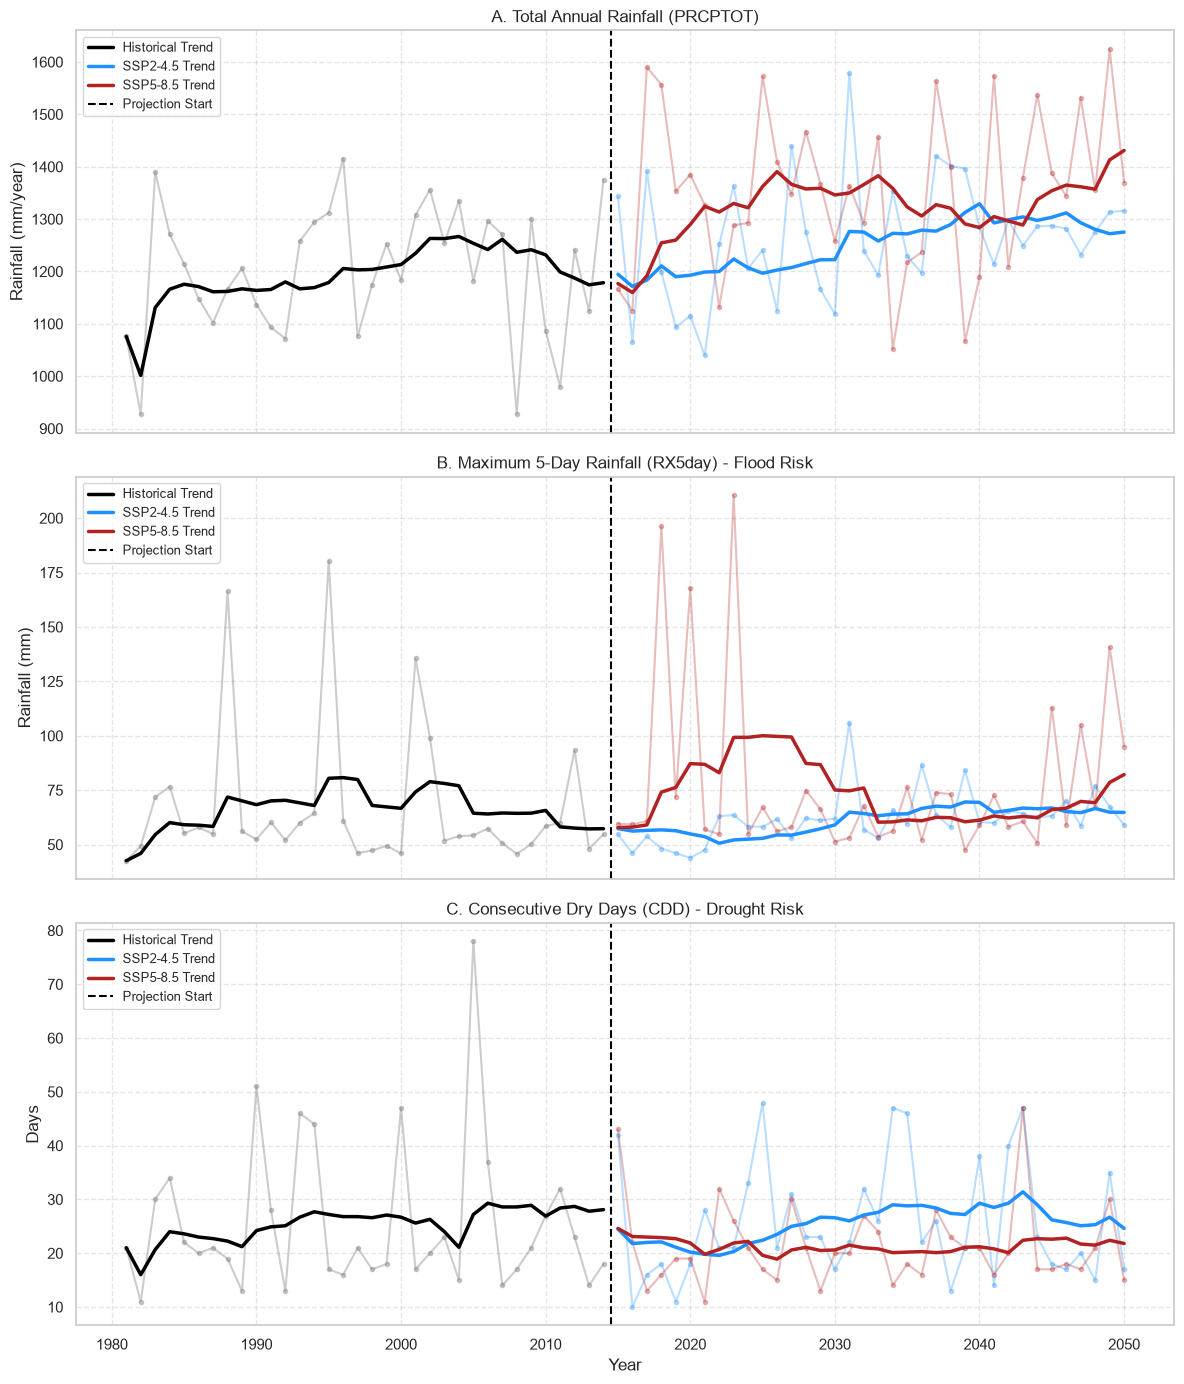

In [20]:
# ==========================================
# CELL 3: TIME SERIES EXTREMES & TRENDLINES
# ==========================================
import matplotlib.pyplot as plt
import pandas as pd

# Combine historical with each future scenario to create continuous timelines (1981-2050)
timeline_245 = pd.concat([hist_extremes, ssp245_extremes]).sort_values('Year').reset_index(drop=True)
timeline_585 = pd.concat([hist_extremes, ssp585_extremes]).sort_values('Year').reset_index(drop=True)

# Define the 10-year rolling mean for smoothing
# min_periods=1 ensures the line starts immediately in 1981
window = 10

def plot_climate_trend(ax, col_name, title, y_label):
    """Plots the raw annual data and the 10-year smoothed trendline."""
    
    # 1. Plot Raw Annual Data (Faded in the background)
    ax.plot(hist_extremes['Year'], hist_extremes[col_name], color='gray', alpha=0.4, linestyle='-', marker='.')
    ax.plot(ssp245_extremes['Year'], ssp245_extremes[col_name], color='dodgerblue', alpha=0.3, linestyle='-', marker='.')
    ax.plot(ssp585_extremes['Year'], ssp585_extremes[col_name], color='firebrick', alpha=0.3, linestyle='-', marker='.')

    # 2. Plot 10-Year Moving Averages (Bold trendlines)
    # Historical Trend (1981-2014)
    hist_trend = hist_extremes[col_name].rolling(window=window, min_periods=1).mean()
    ax.plot(hist_extremes['Year'], hist_trend, color='black', linewidth=2.5, label='Historical Trend')
    
    # Future Trends (We calculate rolling on the combined timeline to prevent a gap at 2015, then slice)
    trend_245 = timeline_245[col_name].rolling(window=window, min_periods=1).mean()
    trend_585 = timeline_585[col_name].rolling(window=window, min_periods=1).mean()
    
    # Plot only the future portion (2015-2050) of the trend
    future_mask_245 = timeline_245['Year'] >= 2015
    future_mask_585 = timeline_585['Year'] >= 2015
    
    ax.plot(timeline_245.loc[future_mask_245, 'Year'], trend_245[future_mask_245], 
            color='dodgerblue', linewidth=2.5, label='SSP2-4.5 Trend')
    ax.plot(timeline_585.loc[future_mask_585, 'Year'], trend_585[future_mask_585], 
            color='firebrick', linewidth=2.5, label='SSP5-8.5 Trend')

    # 3. Formatting and Structure
    ax.axvline(x=2014.5, color='black', linestyle='--', linewidth=1.5, label='Projection Start')
    ax.set_title(title, fontsize=12)
    ax.set_ylabel(y_label)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='upper left', fontsize=9)

# Set up a 3-row layout for the three indices
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 14), sharex=True)

# Generate the three plots
plot_climate_trend(ax1, 'PRCPTOT_mm', 'A. Total Annual Rainfall (PRCPTOT)', 'Rainfall (mm/year)')
plot_climate_trend(ax2, 'RX5day_mm', 'B. Maximum 5-Day Rainfall (RX5day) - Flood Risk', 'Rainfall (mm)')
plot_climate_trend(ax3, 'CDD_days', 'C. Consecutive Dry Days (CDD) - Drought Risk', 'Days')

plt.xlabel('Year', fontsize=12)
plt.tight_layout()
plt.show()

C:\Users\Baikania Amonison\AppData\Local\Temp\ipykernel_3852\135630181.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=combined_extremes, x='Scenario', y='PRCPTOT_mm', ax=ax1, palette=palette_colors, showmeans=True,
C:\Users\Baikania Amonison\AppData\Local\Temp\ipykernel_3852\135630181.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=combined_extremes, x='Scenario', y='RX5day_mm', ax=ax2, palette=palette_colors, showmeans=True,
C:\Users\Baikania Amonison\AppData\Local\Temp\ipykernel_3852\135630181.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the 

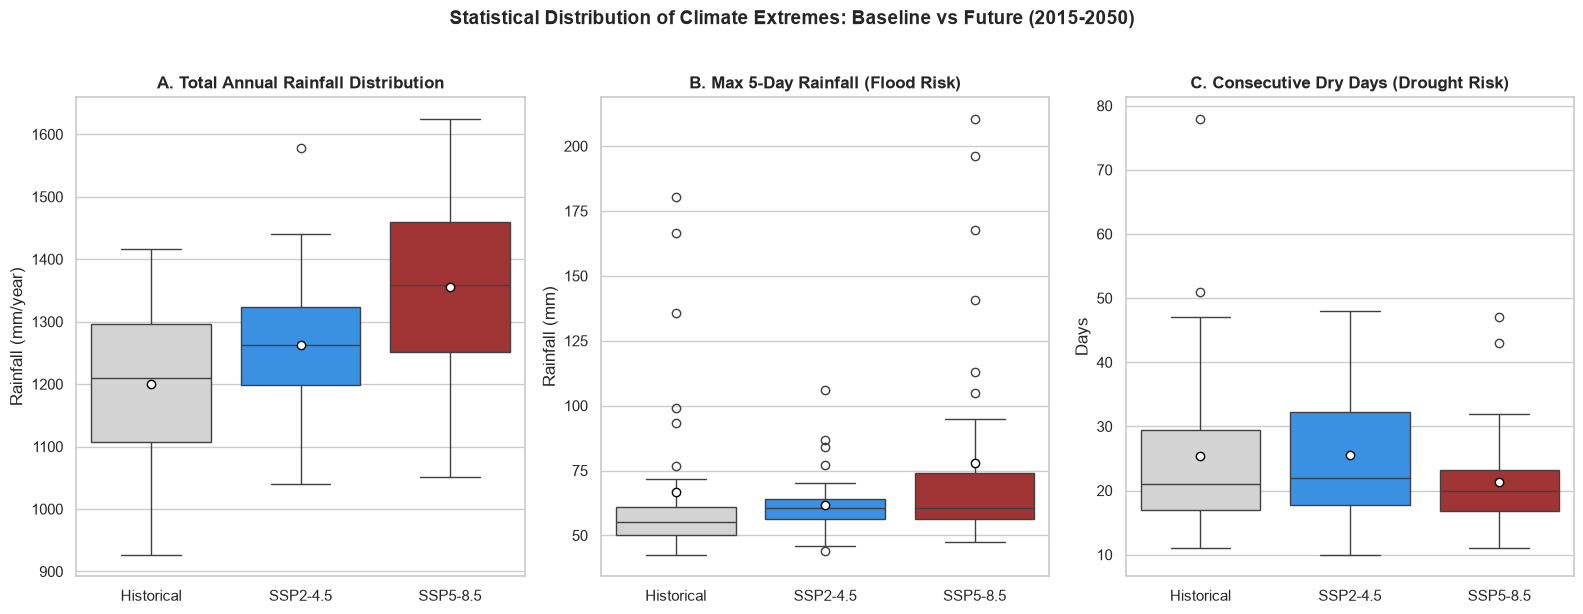

In [21]:
# ==========================================
# CELL 4: STATISTICAL BOX PLOTS (DISTRIBUTION)
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Combine all scenarios into a single DataFrame for Seaborn
combined_extremes = pd.concat([hist_extremes, ssp245_extremes, ssp585_extremes], ignore_index=True)

# Set the visual style
sns.set_theme(style="whitegrid")
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 6))

# Define a custom color palette to match your time-series lines
palette_colors = {'Historical': 'lightgray', 'SSP2-4.5': 'dodgerblue', 'SSP5-8.5': 'firebrick'}

# 2. Generate the Box Plots
# Plot A: PRCPTOT
sns.boxplot(data=combined_extremes, x='Scenario', y='PRCPTOT_mm', ax=ax1, palette=palette_colors, showmeans=True, 
            meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"6"})
ax1.set_title('A. Total Annual Rainfall Distribution', fontsize=12, fontweight='bold')
ax1.set_ylabel('Rainfall (mm/year)')
ax1.set_xlabel('')

# Plot B: RX5day
sns.boxplot(data=combined_extremes, x='Scenario', y='RX5day_mm', ax=ax2, palette=palette_colors, showmeans=True,
            meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"6"})
ax2.set_title('B. Max 5-Day Rainfall (Flood Risk)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Rainfall (mm)')
ax2.set_xlabel('')

# Plot C: CDD
sns.boxplot(data=combined_extremes, x='Scenario', y='CDD_days', ax=ax3, palette=palette_colors, showmeans=True,
            meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"6"})
ax3.set_title('C. Consecutive Dry Days (Drought Risk)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Days')
ax3.set_xlabel('')

# 3. Formatting
plt.suptitle('Statistical Distribution of Climate Extremes: Baseline vs Future (2015-2050)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Calculating and smoothing spatial data... Please wait.


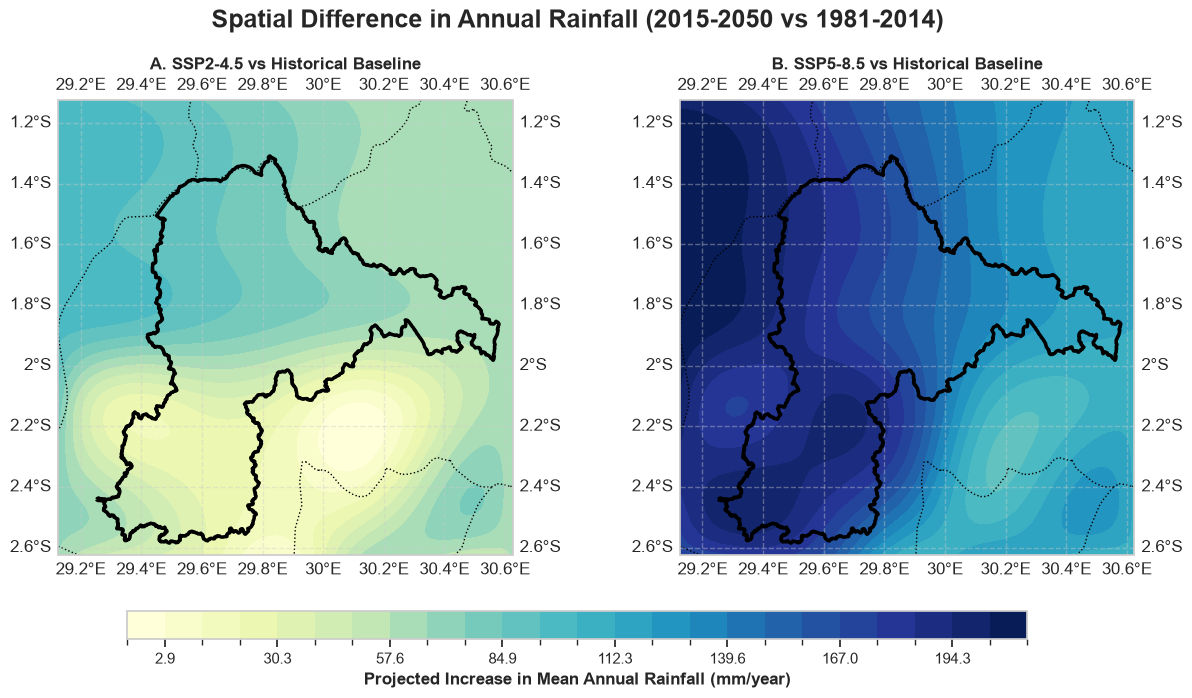

In [22]:
# ==========================================
# CELL 5: PUBLICATION-QUALITY DIFFERENCE MAPS (FINAL)
# ==========================================
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import os
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd

# Define the working directory
base_dir = r"C:\Users\Baikania Amonison\Desktop\final data extraction and analysis"

def get_spatial_annual_mean(filename, start_year, end_year):
    """Loads NetCDF, preserves spatial dimensions, and calculates mean annual rainfall per pixel."""
    filepath = os.path.join(base_dir, filename)
    ds = xr.open_dataset(filepath)
    
    # Slice exactly to the required timeframe
    ds = ds.sel(time=slice(f"{start_year}-01-01", f"{end_year}-12-31"))
    
    # Convert kg/m2/s to mm/day
    pr_mm_day = ds['pr'] * 86400
    
    # Sum the daily rainfall into Annual Totals for each pixel, then average them
    annual_totals = pr_mm_day.groupby('time.year').sum('time')
    return annual_totals.mean('year')

print("Calculating and smoothing spatial data... Please wait.")

# Calculate Spatial Climatologies
hist_spatial = get_spatial_annual_mean("Nyabarongo_pr_historical_aggregated.nc", 1981, 2014)
ssp245_spatial = get_spatial_annual_mean("Nyabarongo_pr_ssp245_aggregated.nc", 2015, 2050)
ssp585_spatial = get_spatial_annual_mean("Nyabarongo_pr_ssp585_aggregated.nc", 2015, 2050)

# Calculate Absolute Difference
diff_245 = ssp245_spatial - hist_spatial
diff_585 = ssp585_spatial - hist_spatial

# --- High-Resolution Interpolation ---
# Extract raw float values using .item() to prevent Xarray/Numpy dimension crashes
lon_min, lon_max = diff_245.lon.min().item(), diff_245.lon.max().item()
lat_min, lat_max = diff_245.lat.min().item(), diff_245.lat.max().item()

new_lon = np.linspace(lon_min, lon_max, 100)
new_lat = np.linspace(lat_min, lat_max, 100)

diff_245_smooth = diff_245.interp(lon=new_lon, lat=new_lat, method='cubic')
diff_585_smooth = diff_585.interp(lon=new_lon, lat=new_lat, method='cubic')

# Load and project the shapefile
shp_path = os.path.join(base_dir, "nyabarongo.shp")
catchment = gpd.read_file(shp_path)
if catchment.crs != "EPSG:4326":
    catchment = catchment.to_crs(epsg=4326)

# Setup Figure Space
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7), subplot_kw={'projection': ccrs.PlateCarree()})

# --- THE LAYOUT FIX ---
# Leaves room at the top for the main title, room at the bottom for the colorbar, 
# and adds breathing room (wspace) between the two maps.
plt.subplots_adjust(top=0.85, bottom=0.2, wspace=0.15)

# Unified Color Scale bounds (apples-to-apples comparison)
vmin = min(diff_245_smooth.min().values, diff_585_smooth.min().values)
vmax = max(diff_245_smooth.max().values, diff_585_smooth.max().values)

# Shared plotting parameters
plot_kwargs = {
    'cmap': 'YlGnBu',          
    'transform': ccrs.PlateCarree(),
    'vmin': vmin,
    'vmax': vmax,
    'levels': 25,              
    'add_colorbar': False      
}

# Plot SSP2-4.5
contour1 = diff_245_smooth.plot.contourf(ax=ax1, **plot_kwargs)
ax1.set_title('A. SSP2-4.5 vs Historical Baseline', fontweight='bold', fontsize=12)
ax1.add_feature(cfeature.BORDERS, linestyle=':')
ax1.gridlines(draw_labels=True, linestyle='--', alpha=0.4)
catchment.boundary.plot(ax=ax1, color='black', linewidth=2.5, transform=ccrs.PlateCarree())

# Plot SSP5-8.5
contour2 = diff_585_smooth.plot.contourf(ax=ax2, **plot_kwargs)
ax2.set_title('B. SSP5-8.5 vs Historical Baseline', fontweight='bold', fontsize=12)
ax2.add_feature(cfeature.BORDERS, linestyle=':')
ax2.gridlines(draw_labels=True, linestyle='--', alpha=0.4)
catchment.boundary.plot(ax=ax2, color='black', linewidth=2.5, transform=ccrs.PlateCarree())

# --- Single Centered Colorbar ---
cbar_ax = fig.add_axes([0.2, 0.08, 0.6, 0.04]) 
cbar = fig.colorbar(contour2, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Projected Increase in Mean Annual Rainfall (mm/year)', fontsize=12, fontweight='bold')

# --- THE TITLE FIX ---
plt.suptitle('Spatial Difference in Annual Rainfall (2015-2050 vs 1981-2014)', fontsize=18, fontweight='bold', y=0.98)
plt.show()